In [ ]:

import os
import sys
sys.path.append(os.path.dirname(os.path.dirname(__file__)))
from configs.config2 import * # directories + constants

import mne
import matplotlib

from utils import raw
from utils.ica import get_outFilePaths
from utils.subj import get_MEG_raw_subjects
import subprocess
from pathlib import Path

os.environ["MNE_BROWSER_BACKEND"] = "matplotlib"
mne.viz.set_browser_backend("matplotlib")

%matplotlib widget
import matplotlib.pyplot as plt

Using matplotlib as 2D backend.


open folder with rejected comp files no the side

In [2]:
# ica_folder = 'ica_qc_099cmp'
# ica_folder = 'ica_qc_095cmp'
ica_folder = 'ica_qc'
# ica_folder = 'ica_qc_095_Infomax'
# folder_rejectedComps = f"/home/reabt/experiments/ncc/MEG/data/{ica_folder}/step3_rejected_comps"
# folder_topoPlots = f"/home/reabt/experiments/ncc/MEG/data/{ica_folder}/step3_comps_topos"

# subprocess.Popen(["code", "--new-window", folder_rejectedComps])
# subprocess.Popen(["code", "--new-window", folder_topoPlots])
plt.close('all')

load data

Removed bad subject: 20050615buea
Subject ID: 19840930bigs
Opening raw data file /home/reabt/experiments/ncc/MEG/data/ica_qc/old_step2_ica_tmp_data/19840930bigs_ica_data.fif...


/tmp/ipykernel_2941888/2823418729.py:15: RuntimeWarning: This filename (/home/reabt/experiments/ncc/MEG/data/ica_qc/old_step2_ica_tmp_data/19840930bigs_ica_data.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(rawFile, preload=False)


    Range : 22600 ... 1119199 =    113.000 ...  5595.995 secs
Ready.
Reading /home/reabt/experiments/ncc/MEG/data/ica_qc/old_step2_ica_comps/19840930bigs_ica.fif ...
Now restoring ICA solution ...
Ready.
Creating RawArray with float64 data, n_channels=53, n_times=1096600
    Range : 22600 ... 1119199 =    113.000 ...  5595.995 secs
Ready.


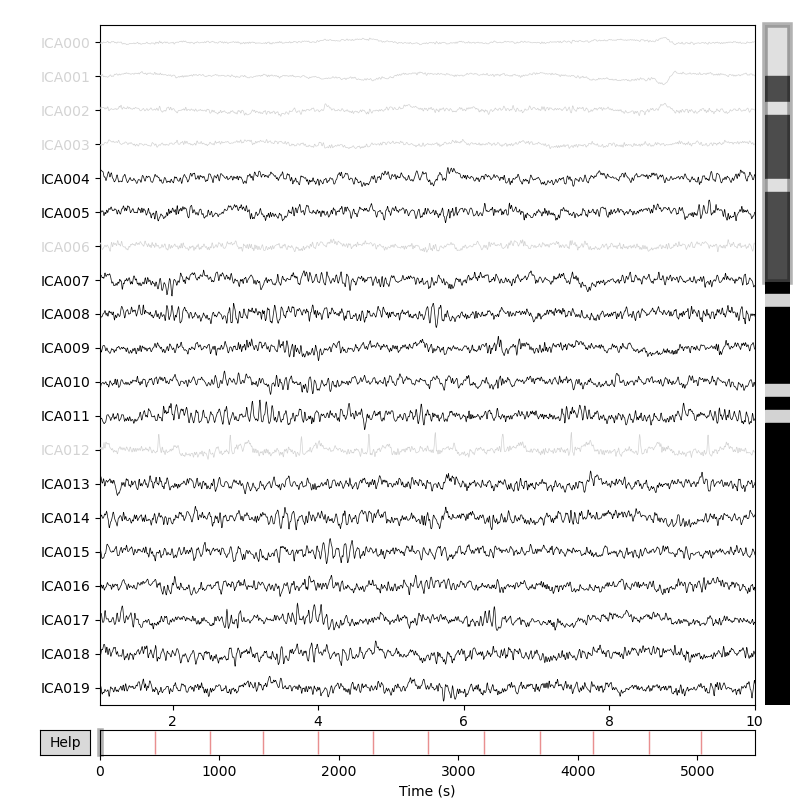

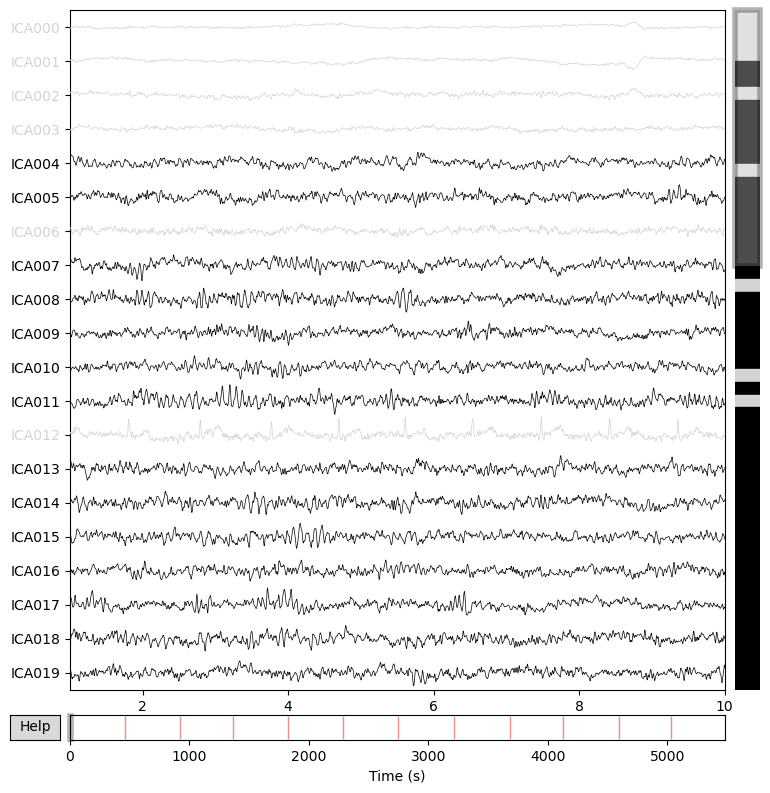

In [6]:
plt.close('all')
all_subjects = get_MEG_raw_subjects()

# subject_id = all_subjects[all_subjects.index('19880331igse')]
subject_id = all_subjects[all_subjects.index('19840930bigs')]

print(f"Subject ID: {subject_id}")

# _, icaPaths = get_outFilePaths(subject_id, out_root="/home/reabt/experiments/ncc/MEG/data/ica_qc")
_, icaPaths = get_outFilePaths(subject_id, out_root=f"/home/reabt/experiments/ncc/MEG/data/{ica_folder}")

rawFile = f'/home/reabt/experiments/ncc/MEG/data/ica_qc/old_step2_ica_tmp_data/{subject_id}_ica_data.fif'
icaFile = f'/home/reabt/experiments/ncc/MEG/data/ica_qc/old_step2_ica_comps/{subject_id}_ica.fif'

raw = mne.io.read_raw_fif(rawFile, preload=False)
ica = mne.preprocessing.read_ica(icaFile)
# raw = raw.filter(l_freq = None , h_freq=40.0, n_jobs=-1)
ica.plot_sources(
    raw,
    show=True,
    block=False,
	# overview_mode=False,
    start = 1,
    stop = 10
    
)

In [4]:
# a = ica.plot_properties(
# 	raw, picks = [43, 45, 49],
# 	figsize = (6, 4), psd_args={'method': 'welch'})

In [5]:
# ica.plot_overlay(raw, picks=[12, 26], exclude=ica.exclude)

# plt.close('all')